In [26]:
import mlflow
from mlflow import MlflowClient

mlflow.set_tracking_uri("http://127.0.0.1:5001")
client = MlflowClient()

# Find the ACC_Training_v2 experiment
experiments = client.search_experiments()
for exp in experiments:
    print(f"{exp.experiment_id}: {exp.name}")

2: Trace_Fix_Test
1: ACC_Training_v2
0: Default


In [27]:
acc_experiment[0]

<Experiment: artifact_location='/data/home/sffc348/Repos/cobbie/.mlflow/mlartifacts/1', creation_time=1770029423468, experiment_id='1', last_update_time=1770029423468, lifecycle_stage='active', name='ACC_Training_v2', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [28]:
# Get the last parent run from ACC_Training_v2
# (adjust experiment_id if needed based on output above)
acc_experiment = [e for e in experiments if e.name == "ACC_Training_v2"]
assert acc_experiment, "ACC_Training_v2 experiment not found"
exp_id = acc_experiment[0].experiment_id

# Fetch the most recent parent run (non-nested)
parent_runs = client.search_runs(
    experiment_ids=[exp_id],
    filter_string='tags.mlflow.parentRunId = ""',
    order_by=["start_time DESC"],
    max_results=5,
)
# If the above returns nothing, parentRunId tag may not exist on parent runs — fall back
if not parent_runs:
    parent_runs = client.search_runs(
        experiment_ids=[exp_id],
        order_by=["start_time DESC"],
        max_results=1,
    )

last_run = parent_runs[0]
print(f"Run ID:   {last_run.info.run_id}")
print(f"Run Name: {last_run.info.run_name}")
print(f"Status:   {last_run.info.status}")
print(f"Start:    {last_run.info.start_time}")
print(f"\nParams:")
for k, v in sorted(last_run.data.params.items()):
    print(f"  {k}: {v}")
print(f"\nTop-level metrics:")
for k, v in sorted(last_run.data.metrics.items()):
    if not k.startswith(("training_", "validation_", "test_", "creator_", "latency_")):
        print(f"  {k}: {v}")

Run ID:   8c563f704e434ca48fed3a625c057109
Run Name: rule_11_slabs_guarded_against_falling
Status:   RUNNING
Start:    1770321158355

Params:
  rule_index: 11
  rule_title: slabs_guarded_against_falling

Top-level metrics:


In [29]:
parent_runs = client.search_runs(
    experiment_ids=[exp_id],
    order_by=["start_time DESC"],
)

len(parent_runs)

59

In [30]:
parent_runs = client.search_runs(
    experiment_ids=[exp_id],
    filter_string='tags.mlflow.parentRunId = "7ca5817aba3e40879b3205398d958102"',
    order_by=["start_time DESC"],
)

len(parent_runs)

23

In [31]:
run_with_traces = []

for run in parent_runs:
    # Fetch traces for this run
    traces = mlflow.search_traces(
        experiment_ids=[exp_id],
        run_id=run.info.run_id,
        return_type="list",
    )
    print(f"Found {len(traces)} traces in run {run.info.run_name} -- Active: {run.info.status}\n")
    run_with_traces.append((run, traces))
# for t in traces:
#     spans = t.data.spans or []
#     print(f"Trace {t.info.request_id}  status={t.info.status}  spans={len(spans)}")
#     for s in spans:
#         print(f"  {s.name}  [{s.span_type}]  status={s.status}")

/var/folders/nh/sj47dvbx7p9dd_l626f7j3700000gn/T/ipykernel_20733/406542738.py:5: FutureWarning: Parameter 'experiment_ids' is deprecated. Please use 'locations' instead.
  traces = mlflow.search_traces(


Found 0 traces in run rule_11_slabs_guarded_against_falling -- Active: RUNNING

Found 0 traces in run rule_13_space_validation_intersect -- Active: FINISHED

Found 0 traces in run rule_11_slabs_guarded_against_falling -- Active: FINISHED

Found 1 traces in run rule_14_spaces_same_storey_same_bottom_elevation -- Active: FINISHED

Found 0 traces in run rule_13_space_validation_intersect -- Active: RUNNING

Found 0 traces in run rule_7_clearance_front_of_doors -- Active: RUNNING

Found 0 traces in run rule_13_space_validation_intersect -- Active: RUNNING

Found 1 traces in run rule_15_unallocated_areas -- Active: FINISHED

Found 1 traces in run rule_4_504_2_non_uniform_risers_treads -- Active: FINISHED

Found 0 traces in run rule_11_slabs_guarded_against_falling -- Active: FINISHED

Found 1 traces in run rule_10_slab_thickness -- Active: FINISHED

Found 1 traces in run rule_9_large_spaces_more_than_one_door -- Active: FINISHED

Found 1 traces in run rule_8_doors_and_windows -- Active: FIN

In [32]:
# Ordered by run name
sorted([(len(t), r.info.run_name) for r, t in run_with_traces])

[(0, 'rule_11_slabs_guarded_against_falling'),
 (0, 'rule_11_slabs_guarded_against_falling'),
 (0, 'rule_11_slabs_guarded_against_falling'),
 (0, 'rule_11_slabs_guarded_against_falling'),
 (0, 'rule_12_space_validation_inside'),
 (0, 'rule_13_space_validation_intersect'),
 (0, 'rule_13_space_validation_intersect'),
 (0, 'rule_13_space_validation_intersect'),
 (0, 'rule_4_504_2_non_uniform_risers_treads'),
 (0, 'rule_7_clearance_front_of_doors'),
 (0, 'rule_7_clearance_front_of_doors'),
 (1, 'rule_0_304_3_1_circular_space'),
 (1, 'rule_10_slab_thickness'),
 (1, 'rule_14_spaces_same_storey_same_bottom_elevation'),
 (1, 'rule_15_unallocated_areas'),
 (1, 'rule_1_305_3_size'),
 (1, 'rule_2_404_2_5_two_doors_in_series'),
 (1, 'rule_3_504_2_stair_slab_connection'),
 (1, 'rule_4_504_2_non_uniform_risers_treads'),
 (1, 'rule_5_504_2_riser_height'),
 (1, 'rule_6_504_2_tread_length'),
 (1, 'rule_8_doors_and_windows'),
 (1, 'rule_9_large_spaces_more_than_one_door')]

In [17]:
import pandas as pd

# Build enriched DataFrame from run_with_traces
rows = []
for r, t in run_with_traces:
    m = r.data.metrics
    run_name = r.info.run_name
    # Parse rule index from run_name (e.g. "rule_11_slabs_..." -> 11)
    try:
        rule_index = int(run_name.split("_")[1])
    except (IndexError, ValueError):
        rule_index = None

    rows.append({
        "run_name": run_name,
        "run_id": r.info.run_id,
        "status": r.info.status,
        "trace_count": len(t),
        "has_trace": len(t) > 0,
        "start_time": pd.to_datetime(r.info.start_time, unit="ms"),
        "end_time": pd.to_datetime(r.info.end_time, unit="ms") if r.info.end_time else pd.NaT,
        "total_duration_s": m.get("total_duration"),
        "create_tool_duration_s": m.get("create_tool_duration"),
        "assessment_duration_s": m.get("assessment_duration"),
        "total_tokens": m.get("total_tokens"),
        "create_tool_tokens": m.get("create_tool_tokens"),
        "retry_count": m.get("retry_count", 0),
        "rule_index": rule_index,
    })

df_traces = pd.DataFrame(rows).sort_values("start_time").reset_index(drop=True)

# Flag duplicates: run_name appears more than once
name_counts = df_traces["run_name"].value_counts()
df_traces["is_duplicate"] = df_traces["run_name"].map(lambda n: name_counts[n] > 1)

df_traces

,run_name,run_id,status,trace_count,has_trace,start_time,end_time,total_duration_s,create_tool_duration_s,assessment_duration_s,total_tokens,create_tool_tokens,retry_count,rule_index,is_duplicate
0,rule_0_304_3_1_circular_space,544542d3af934d4883fd9e9124f4033f,FINISHED,1,True,2026-02-04 19:57:17.488,2026-02-04 20:13:56.831,979.248853,920.666313,27.943660,537669.0,530001.0,2.0,0,False
1,rule_1_305_3_size,9f91f80700554f5194cf808e50e3f435,FINISHED,1,True,2026-02-04 20:16:33.731,2026-02-04 20:43:25.345,1590.498693,1371.345986,43.008385,1082762.0,1072351.0,2.0,1,False
2,rule_2_404_2_5_two_doors_in_series,56c1dd3692e94ecc98a6befc4dda0055,FINISHED,1,True,2026-02-04 20:43:28.722,2026-02-04 21:08:10.975,886.691596,814.514839,39.314141,1213789.0,1207490.0,2.0,2,False
3,rule_3_504_2_stair_slab_connection,32adbcad3a4542e4ab0e3bbb02aec775,FINISHED,1,True,2026-02-04 21:08:14.407,2026-02-04 21:11:26.145,190.146941,180.815118,0.000000,108103.0,108103.0,0.0,3,False
4,rule_4_504_2_non_uniform_risers_treads,5bcda601d75e4da79deed4d7c8814bbf,FINISHED,0,False,2026-02-04 21:11:29.368,2026-02-05 00:26:32.070,648.317375,605.814308,24.078584,799341.0,794922.0,2.0,4,True
5,rule_5_504_2_riser_height,902ac82e4d3c4825815c8b35872e1bac,FINISHED,1,True,2026-02-05 00:26:35.174,2026-02-05 01:04:26.649,976.412847,937.420835,23.113170,686311.0,682567.0,2.0,5,False
6,rule_6_504_2_tread_length,44695faccae24ceaacf4254f13348b3d,FINISHED,1,True,2026-02-05 01:04:29.956,2026-02-05 01:22:27.688,1044.480619,820.492851,201.525718,410602.0,400463.0,2.0,6,False
7,rule_7_clearance_front_of_doors,6511cd86b4bf40849008d1cd42a59b3c,FINISHED,0,False,2026-02-05 04:56:08.349,2026-02-05 06:57:57.879,6504.697217,4665.260843,298.716887,1505926.0,1489992.0,2.0,7,True
8,rule_11_slabs_guarded_against_falling,6fee52f34adb4be1b2014d486c9cd1d8,FINISHED,0,False,2026-02-05 05:02:25.365,2026-02-05 06:05:05.220,3568.094504,2802.128971,367.083259,1215746.0,1200810.0,2.0,11,True
9,rule_12_space_validation_inside,660161c46004419ba6a1a5a9527ea71a,FINISHED,0,False,2026-02-05 06:05:08.292,2026-02-05 07:18:18.770,3007.852642,2501.433060,112.707264,982612.0,977416.0,2.0,12,False


In [18]:
# Group comparison: FINISHED runs only (RUNNING ones obviously lack traces)
df_finished = df_traces[df_traces["status"] == "FINISHED"].copy()

metric_cols = [
    "total_duration_s", "create_tool_duration_s", "assessment_duration_s",
    "total_tokens", "create_tool_tokens", "retry_count",
]

print("=== Mean metrics by has_trace (FINISHED runs only) ===\n")
display(df_finished.groupby("has_trace")[metric_cols].mean().T)

print("\n=== Duplicate distribution per group ===\n")
display(df_finished.groupby("has_trace")["is_duplicate"].value_counts().unstack(fill_value=0))

print("\n=== Start time stats per group ===\n")
display(df_finished.groupby("has_trace")["start_time"].agg(["min", "max", "count"]))

=== Mean metrics by has_trace (FINISHED runs only) ===



has_trace,False,True
total_duration_s,3.546922e+03,1141.738910
create_tool_duration_s,2.544708e+03,1037.054619
assessment_duration_s,2.008279e+02,59.441568
total_tokens,1.073734e+06,680960.250000
create_tool_tokens,1.063306e+06,675070.833333
retry_count,2.000000e+00,1.416667



=== Duplicate distribution per group ===



is_duplicate,False,True
has_trace,,
False,1,5
True,11,1



=== Start time stats per group ===



,min,max,count
has_trace,,,
False,2026-02-04 21:11:29.368,2026-02-05 15:05:13.305,6
True,2026-02-04 19:57:17.488,2026-02-05 14:00:30.124,12


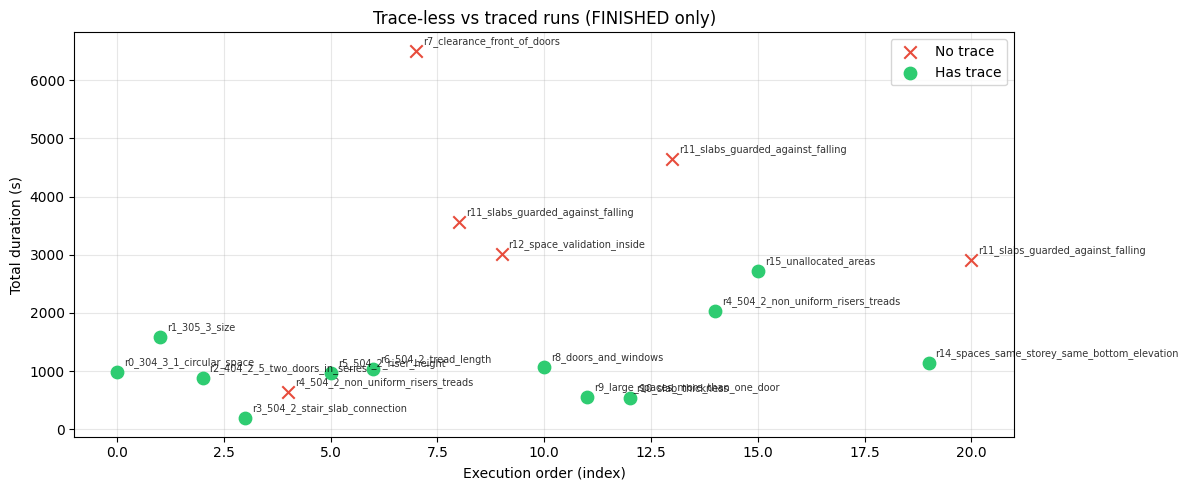

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for has_trace, group in df_finished.groupby("has_trace"):
    label = "Has trace" if has_trace else "No trace"
    color = "#2ecc71" if has_trace else "#e74c3c"
    marker = "o" if has_trace else "x"
    ax.scatter(
        group.index,  # execution order
        group["total_duration_s"],
        c=color, marker=marker, s=80, label=label, zorder=3,
    )
    for _, row in group.iterrows():
        ax.annotate(
            row["run_name"].replace("rule_", "r"),
            (row.name, row["total_duration_s"]),
            textcoords="offset points", xytext=(5, 5),
            fontsize=7, alpha=0.8,
        )

ax.set_xlabel("Execution order (index)")
ax.set_ylabel("Total duration (s)")
ax.set_title("Trace-less vs traced runs (FINISHED only)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Get all nested (per-rule) child runs
child_runs = client.search_runs(
    experiment_ids=[exp_id],
    filter_string=f'tags.mlflow.parentRunId = "{last_run.info.run_id}"',
    order_by=["start_time ASC"],
    max_results=100,
)
print(f"Found {len(child_runs)} child runs (rules)\n")

# Build summary table
rows = []
for r in child_runs:
    m = r.data.metrics
    p = r.data.params
    t = r.data.tags
    rows.append({
        "rule": p.get("rule_title", r.info.run_name),
        "best_f1": m.get("best_f1"),
        "train_f1": m.get("training_f1_aggregated"),
        "val_f1": m.get("validation_f1_aggregated"),
        "test_f1": m.get("test_f1_aggregated"),
        "retries": m.get("retry_count", 0),
        "saved": bool(m.get("tool_saved", 0)),
        "total_tokens": m.get("total_tokens", 0),
        "total_duration_s": round(m.get("total_duration", 0), 1),
        "diagnosis": t.get("assessment_diagnosis", ""),
    })

df = pd.DataFrame(rows)
df

In [ ]:
# Summary statistics
print(f"Rules processed: {len(df)}")
print(f"Tools saved:     {df['saved'].sum()}")
print(f"Mean best F1:    {df['best_f1'].mean():.3f}")
print(f"Mean val F1:     {df['val_f1'].mean():.3f}")
if df["test_f1"].notna().any():
    print(f"Mean test F1:    {df['test_f1'].mean():.3f}")
print(f"Total tokens:    {df['total_tokens'].sum():,.0f}")
print(f"Total duration:  {df['total_duration_s'].sum():,.0f}s ({df['total_duration_s'].sum()/60:.1f}min)")
print(f"\nDiagnosis distribution:")
print(df["diagnosis"].value_counts().to_string())

In [20]:

# Query trace and span counts via the MLflow client
import mlflow
from mlflow import MlflowClient

mlflow.set_tracking_uri("http://127.0.0.1:5001")
client = MlflowClient()

# Count traces per experiment
for exp in client.search_experiments():
    traces = mlflow.search_traces(
        experiment_ids=[exp.experiment_id],
        return_type="list",
        max_results=1,  # just to check if there are any
    )
    print(f"Experiment {exp.experiment_id} ({exp.name}): at least {len(traces)} traces")


/var/folders/nh/sj47dvbx7p9dd_l626f7j3700000gn/T/ipykernel_20733/463091076.py:10: FutureWarning: Parameter 'experiment_ids' is deprecated. Please use 'locations' instead.
  traces = mlflow.search_traces(


Experiment 2 (Trace_Fix_Test): at least 1 traces
Experiment 1 (ACC_Training_v2): at least 1 traces
Experiment 0 (Default): at least 0 traces


In [21]:

# Get ALL traces for ACC_Training_v2 - paginate to count them all
all_traces = mlflow.search_traces(
    experiment_ids=["1"],
    return_type="list",
    max_results=1000,
)
print(f"Total traces in ACC_Training_v2: {len(all_traces)}")

# Check span counts per trace
span_counts = []
for t in all_traces:
    spans = t.data.spans or []
    span_counts.append(len(spans))

print(f"Total spans across all traces: {sum(span_counts)}")
print(f"Spans per trace: min={min(span_counts)}, max={max(span_counts)}, mean={sum(span_counts)/len(span_counts):.1f}")


/var/folders/nh/sj47dvbx7p9dd_l626f7j3700000gn/T/ipykernel_20733/2515244000.py:2: FutureWarning: Parameter 'experiment_ids' is deprecated. Please use 'locations' instead.
  all_traces = mlflow.search_traces(
2026/02/05 19:29:22 WARNING mlflow.tracing.client: Failed to download trace data for trace 'tr-763494179b04255d11cf4fc1313d26fd' with path=/data/home/sffc348/Repos/cobbie/.mlflow/mlartifacts/1/traces/tr-763494179b04255d11cf4fc1313d26fd/artifacts/traces.json. For full traceback, set logging level to DEBUG.
2026/02/05 19:29:22 WARNING mlflow.tracing.client: Failed to download trace data for trace 'tr-e2c497cd59b0261ffc77ea821d81050c' with path=/data/home/sffc348/Repos/cobbie/.mlflow/mlartifacts/1/traces/tr-e2c497cd59b0261ffc77ea821d81050c/artifacts/traces.json. For full traceback, set logging level to DEBUG.
2026/02/05 19:29:22 WARNING mlflow.tracing.client: Failed to download trace data for trace 'tr-2242edae0e5bdbcb7629510d0020a2da' with path=/data/home/sffc348/Repos/cobbie/.mlflow

Total traces in ACC_Training_v2: 28
Total spans across all traces: 2768
Spans per trace: min=4, max=163, mean=98.9
